# 🏠 Лаборатория: статистика, которая врёт — РЕАЛЬНЫЕ данные
### EDA · California Housing (перепись 1990) · YDL 2026 · Неделя 2, День 1 (часть 2)

> Первый датасет (Smart Traffic) оказался синтетическим шумом — там статистика «врала» от пустоты.
> Теперь берём **настоящие данные** и смотрим, как они врут **по-другому**: перекос, выбросы,
> цензурирование и реальный confounding. Та же методика расследования, противоположная картина.

**Датасет:** `sklearn.datasets.fetch_california_housing` — 20 640 жилых районов Калифорнии.
Признаки: медианный доход (`MedInc`, десятки тыс. $), возраст домов, среднее число комнат/спален,
население, заселённость, широта/долгота и цель — **медианная цена дома** (`MedHouseVal`, сотни тыс. $).

> ⚠️ **Спойлер:** здесь почти нет пропусков, но данные совсем не «чистые». Цена дома **обрезана сверху**
> на $500 001 (цензура), у заселённости есть район с 1243 жильцами на дом (выброс-ошибка),
> а «очевидная» связь *больше комнат → дороже* **переворачивается**, стоит учесть доход. Ловим всё это по шагам.

## 0. Подготовка и загрузка (офлайн, из sklearn)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.datasets import fetch_california_housing

pd.set_option('display.max_columns', None); pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid', palette='deep'); plt.rcParams['figure.dpi'] = 110
RNG = np.random.default_rng(42)

raw = fetch_california_housing(as_frame=True)
df = raw.frame.copy()
print('Размер:', df.shape)
print('Цель: MedHouseVal — медианная цена дома в районе (в сотнях тысяч $)')
df.head()

Размер: (20640, 9)
Цель: MedHouseVal — медианная цена дома в районе (в сотнях тысяч $)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
df.info()
num_cols = ['MedInc','HouseAge','AveRooms','AveBedrms','Population','AveOccup','MedHouseVal']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


## 1. Качество данных — привычка №2

Пропусков нет. Но «нет пропусков» ≠ «данные чистые» — ищем скрытые дефекты глубже.

In [3]:
quality = pd.DataFrame({
    'dtype'    : df.dtypes.astype(str),
    'n_null'   : df.isna().sum(),
    'null_%'   : (df.isna().mean()*100).round(2),
    'n_unique' : df.nunique(),
    'min'      : df.min(numeric_only=True),
    'max'      : df.max(numeric_only=True),
})
print('Дубликатов строк:', df.duplicated().sum())
quality

Дубликатов строк: 0


,dtype,n_null,null_%,n_unique,min,max
MedInc,float64,0,0.0,12928,0.499900,15.000100
HouseAge,float64,0,0.0,52,1.000000,52.000000
AveRooms,float64,0,0.0,19392,0.846154,141.909091
AveBedrms,float64,0,0.0,14233,0.333333,34.066667
Population,float64,0,0.0,3888,3.000000,35682.000000
AveOccup,float64,0,0.0,18841,0.692308,1243.333333
Latitude,float64,0,0.0,862,32.540000,41.950000
Longitude,float64,0,0.0,844,-124.350000,-114.310000
MedHouseVal,float64,0,0.0,3842,0.149990,5.000010


In [4]:
# Скрытый дефект №1 — ЦЕНЗУРА: сколько домов «упёрлись» в потолок цены?
cap = df['MedHouseVal'].max()
n_cap = (df['MedHouseVal'] >= cap - 1e-6).sum()
print(f'Максимум цены = {cap:.5f} (= $500 001).')
print(f'Ровно на потолке: {n_cap} районов ({n_cap/len(df)*100:.1f}%).')
print('Это не настоящие цены, а обрезка сверху — все дороже $500k записаны как $500k.\n')
# Скрытый дефект №2 — невозможные выбросы
print('AveRooms : медиана = {:.1f}, а максимум = {:.1f} комнат на жильё (?!)'.format(
      df['AveRooms'].median(), df['AveRooms'].max()))
print('AveOccup : медиана = {:.1f}, а максимум = {:.1f} человек на жильё (?!)'.format(
      df['AveOccup'].median(), df['AveOccup'].max()))

Максимум цены = 5.00001 (= $500 001).
Ровно на потолке: 965 районов (4.7%).
Это не настоящие цены, а обрезка сверху — все дороже $500k записаны как $500k.

AveRooms : медиана = 5.2, а максимум = 141.9 комнат на жильё (?!)
AveOccup : медиана = 2.8, а максимум = 1243.3 человек на жильё (?!)


**Вердикт по качеству.** Формально 0 пропусков, 0 дублей — но это обманчивая чистота:
1. **Цензура цели:** ~4.8% районов искусственно «обрезаны» на $500k. Любая статистика по цене будет занижена.
2. **Невозможные выбросы:** районы со средними 142 комнатами и 1243 жильцами на дом — это ошибки/крошечные районы.

В синтетике дефектом была *слишком идеальная* чистота. Здесь дефекты реальные и их нужно учитывать в каждом выводе.

## 2. Допрос колонки `MedHouseVal` (цена дома)

Среднее, медиана, std, квартили — и главный вопрос: **расходятся ли среднее и медиана?**

In [5]:
s = df['MedHouseVal']
Q1,Q2,Q3 = s.quantile([.25,.5,.75])
for k,v in {
    'count':int(s.count()),'mean':round(s.mean(),3),'median':round(s.median(),3),
    'std':round(s.std(),3),'min':round(s.min(),3),'Q1':round(Q1,3),'Q3':round(Q3,3),
    'max':round(s.max(),3),'IQR':round(Q3-Q1,3),'mean - median':round(s.mean()-s.median(),3),
    'skew (перекос)':round(s.skew(),3),'CV %':round(s.std()/s.mean()*100,1),
}.items(): print(f'  {k:16s}: {v}')

  count           : 20640
  mean            : 2.069
  median          : 1.797
  std             : 1.154
  min             : 0.15
  Q1              : 1.196
  Q3              : 2.647
  max             : 5.0
  IQR             : 1.451
  mean - median   : 0.272
  skew (перекос)  : 0.978
  CV %            : 55.8


**Протокол.** `mean = 2.07` заметно **больше** `median = 1.80` (разрыв +0.27, ~15%), `skew ≈ +0.98` →
распределение **скошено вправо**: дорогих районов меньше, но они тянут среднее вверх.

В отличие от синтетики, где `mean ≈ median`, **здесь среднее уже врёт**: «средняя» цена 2.07 выше,
чем у типичного района (1.80). Для скошенных данных честнее опираться на медиану. А ещё помним про цензуру —
истинное среднее ещё выше, потому что дорогие дома обрезаны (раздел 8).

## 3. Форма распределения + нормальность (задание №4)

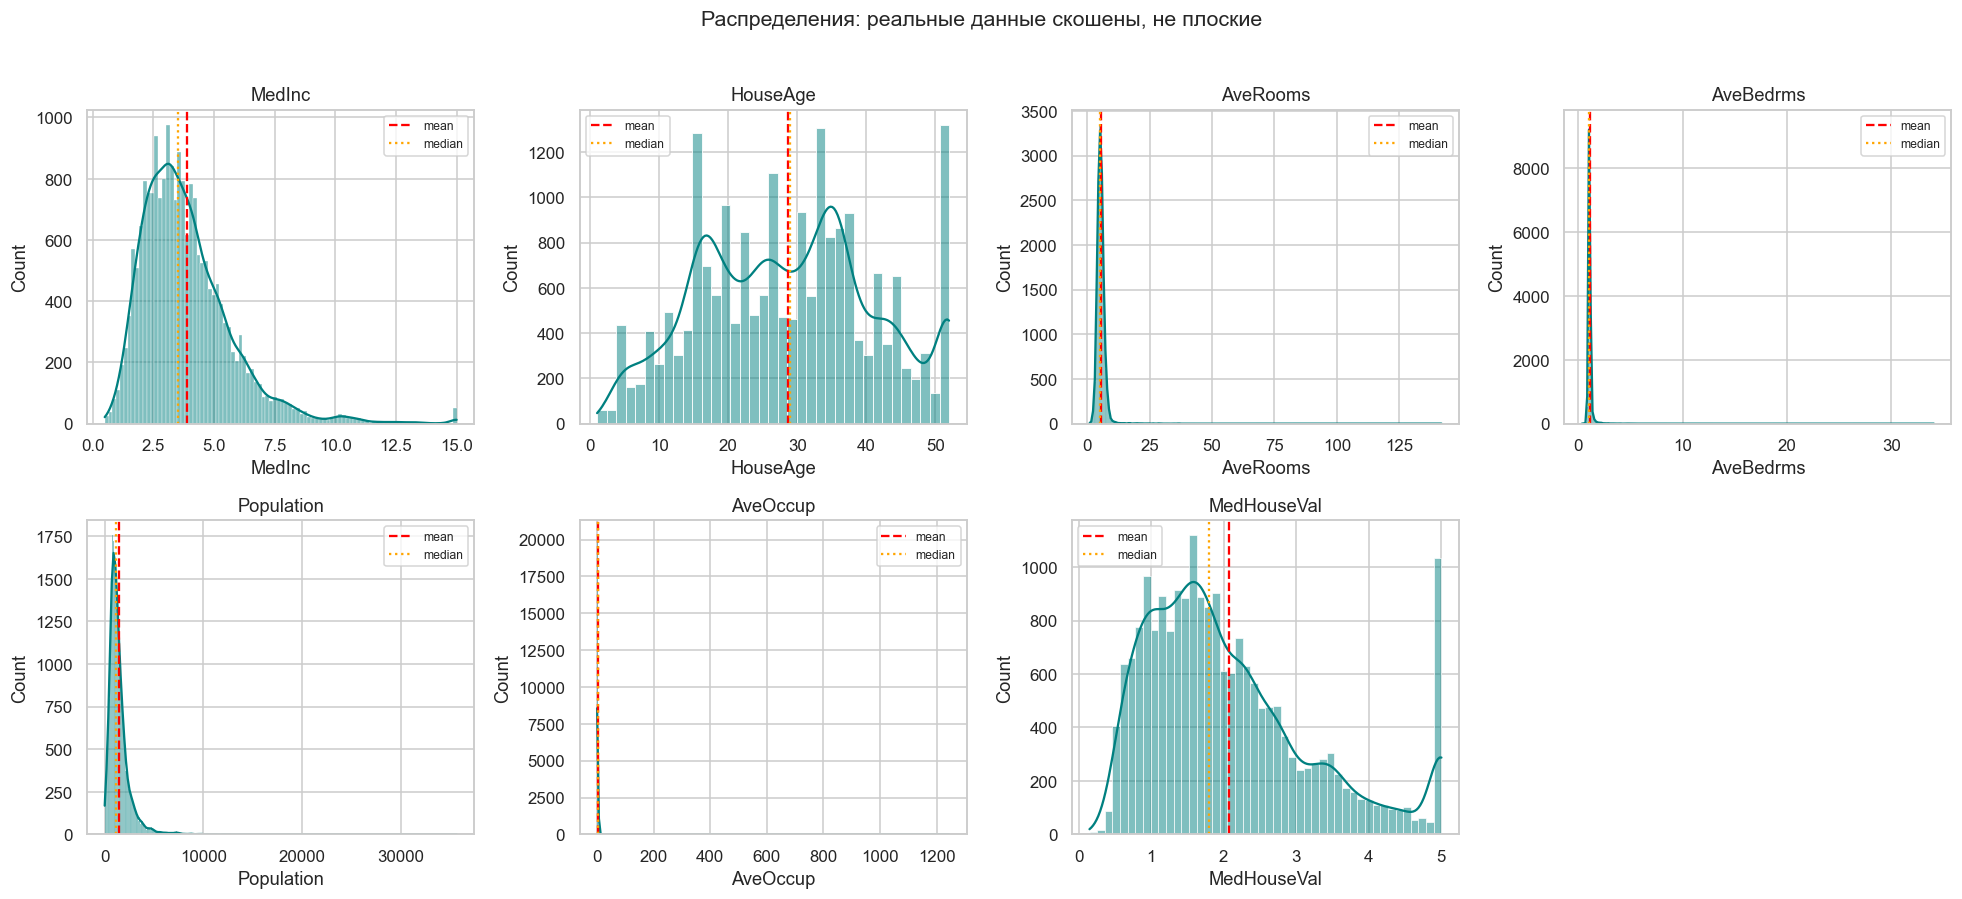

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='teal', edgecolor='white')
    ax.axvline(df[col].mean(),   color='red',   ls='--', lw=1.5, label='mean')
    ax.axvline(df[col].median(), color='orange',ls=':',  lw=1.5, label='median')
    ax.set_title(col); ax.legend(fontsize=8)
axes.ravel()[-1].axis('off')
plt.suptitle('Распределения: реальные данные скошены, не плоские', y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

In [7]:
rows=[]
for col in num_cols:
    samp = df[col].sample(min(500,len(df)), random_state=42)
    _,p_sh = stats.shapiro(samp); _,p_da = stats.normaltest(df[col])
    rows.append({'feature':col,'shapiro_p':p_sh,'dagostino_p':p_da,'skew':round(df[col].skew(),2),
                 'нормальное?':'да' if min(p_sh,p_da)>0.05 else 'НЕТ'})
pd.DataFrame(rows).set_index('feature')

,shapiro_p,dagostino_p,skew,нормальное?
feature,,,,
MedInc,1.093160e-21,0.0,1.65,НЕТ
HouseAge,1.996198e-06,0.0,0.06,НЕТ
AveRooms,7.608104e-32,0.0,20.70,НЕТ
AveBedrms,1.275098e-38,0.0,31.32,НЕТ
Population,3.187009e-24,0.0,4.94,НЕТ
AveOccup,5.864930e-09,0.0,97.64,НЕТ
MedHouseVal,9.290310e-17,0.0,0.98,НЕТ


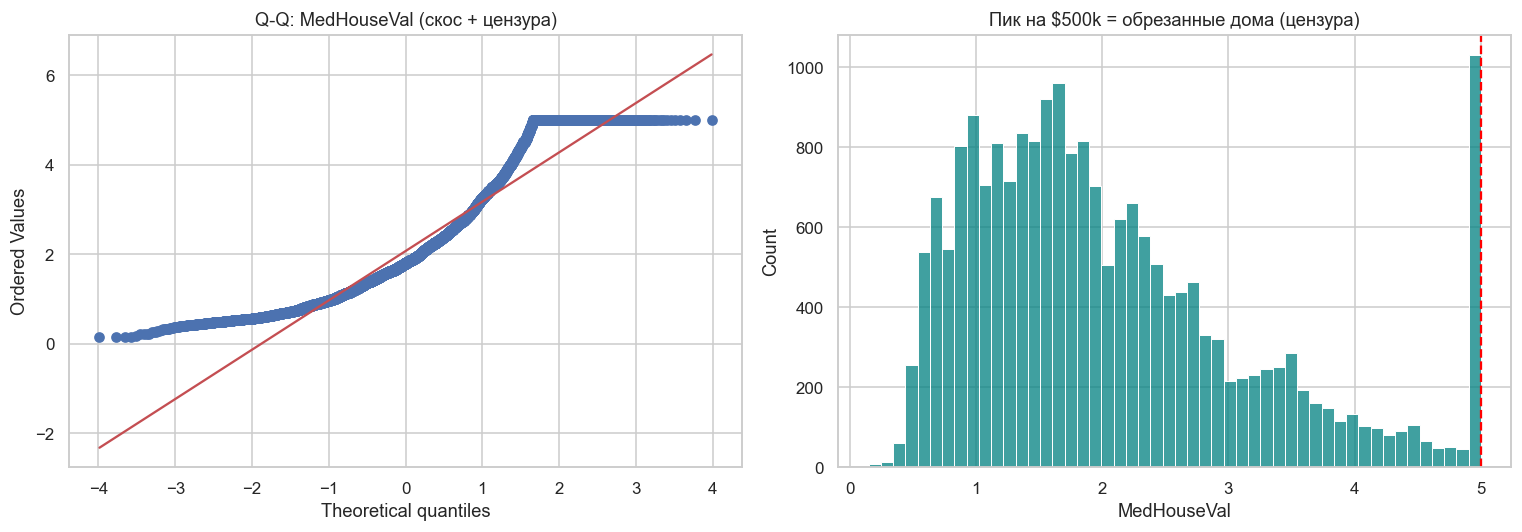

In [8]:
# Q-Q график цены: видно правый скос и «полку» цензуры наверху
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
stats.probplot(df['MedHouseVal'], dist='norm', plot=ax[0]); ax[0].set_title('Q-Q: MedHouseVal (скос + цензура)')
sns.histplot(df['MedHouseVal'], bins=50, ax=ax[1], color='teal')
ax[1].axvline(5.0, color='red', ls='--'); ax[1].set_title('Пик на $500k = обрезанные дома (цензура)')
plt.tight_layout(); plt.show()

**Вердикт по форме.** Нормальность отвергнута везде — но **причина другая, чем в синтетике**.
Там были плоские равномерные «столешницы»; здесь — **правый скос** (доход, население, цена) и
аномальный **пик на $500k** у цены (цензура видна глазом как столбик у правого края).
Q-Q отклоняется вверх на хвосте — почерк скошенных, а не равномерных данных.

## 4. Box plot + выбросы (задание №5): здесь они НАСТОЯЩИЕ

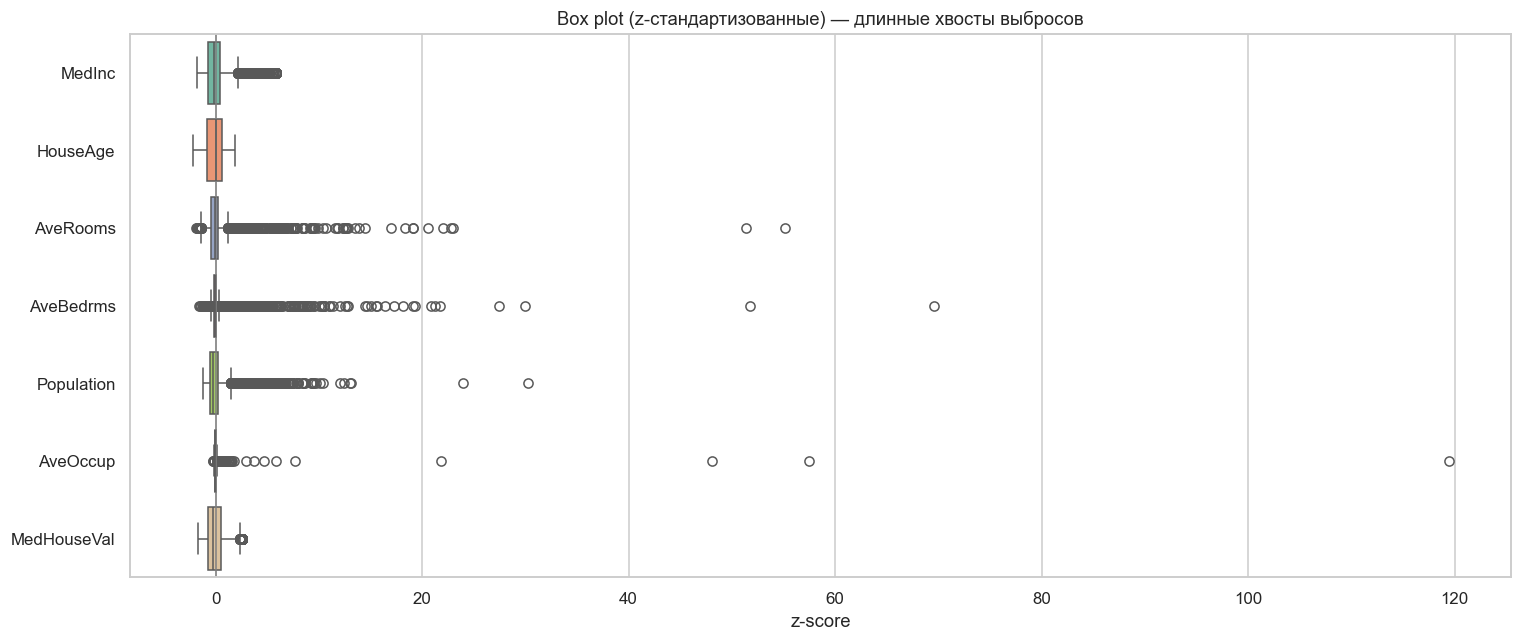

In [9]:
z = (df[num_cols]-df[num_cols].mean())/df[num_cols].std()
plt.figure(figsize=(14,6)); sns.boxplot(data=z, orient='h', palette='Set2')
plt.axvline(0,color='gray',lw=1); plt.title('Box plot (z-стандартизованные) — длинные хвосты выбросов')
plt.xlabel('z-score'); plt.tight_layout(); plt.show()

In [10]:
rows=[]
for col in num_cols:
    sc=df[col]; Q1,Q3=sc.quantile([.25,.75]); IQR=Q3-Q1
    zc=(sc-sc.mean())/sc.std()
    rows.append({'feature':col,'выбросов_IQR':int(((sc<Q1-1.5*IQR)|(sc>Q3+1.5*IQR)).sum()),
                 '|z|>3':int((zc.abs()>3).sum()),'макс |z|':round(zc.abs().max(),1)})
pd.DataFrame(rows).set_index('feature')

,выбросов_IQR,|z|>3,макс |z|
feature,,,
MedInc,681,345,5.9
HouseAge,0,0,2.2
AveRooms,511,133,55.2
AveBedrms,1424,145,69.6
Population,1196,342,30.2
AveOccup,711,8,119.4
MedHouseVal,1071,0,2.5


In [11]:
# Как ОДИН выброс ломает среднее: AveOccup (есть район с 1243 чел/дом)
ao = df['AveOccup']
trimmed = ao[ao < ao.quantile(0.99)]
print(f'AveOccup: mean = {ao.mean():.2f}, median = {ao.median():.2f}, '
      f'mean без верхнего 1% = {trimmed.mean():.2f}, максимум = {ao.max():.0f}')
print('-> Несколько ошибочных районов раздувают среднюю заселённость. Медиана устойчива, среднее — нет.')

AveOccup: mean = 3.07, median = 2.82, mean без верхнего 1% = 2.89, максимум = 1243
-> Несколько ошибочных районов раздувают среднюю заселённость. Медиана устойчива, среднее — нет.


**Вердикт по выбросам.** В отличие от синтетики (0 выбросов), здесь хвосты длинные и реальные:
тысячи точек за усами, `|z|` доходит до десятков. Один район с заселённостью 1243 чел/дом тянет
*среднее* `AveOccup` заметно выше *медианы*. Урок: на реальных данных к среднему всегда прикладывай медиану —
один выброс умеет соврать за всю колонку.

## 5. Корреляции (задание №2): здесь связь ЕСТЬ

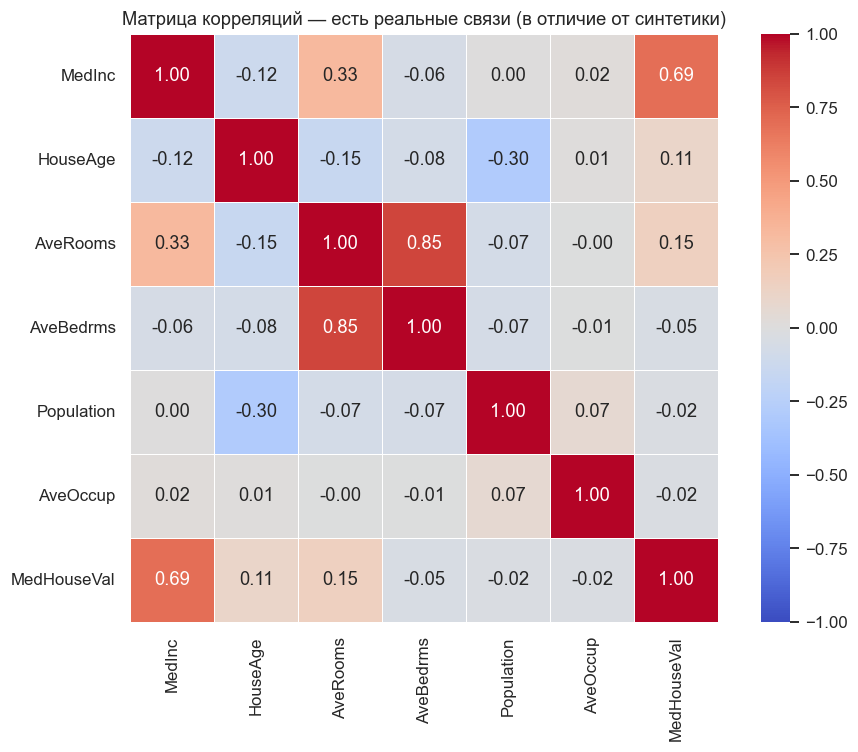

In [12]:
corr = df[num_cols].corr()
plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True, linewidths=.5)
plt.title('Матрица корреляций — есть реальные связи (в отличие от синтетики)')
plt.tight_layout(); plt.show()

In [13]:
r,p = stats.pearsonr(df['MedInc'], df['MedHouseVal'])
print(f'MedInc ~ MedHouseVal : r = {r:.3f},  p = {p:.2e}')
print('Доход — сильнейший и осмысленный предиктор цены. Это НАСТОЯЩАЯ связь, а не шум.')

MedInc ~ MedHouseVal : r = 0.688,  p = 0.00e+00
Доход — сильнейший и осмысленный предиктор цены. Это НАСТОЯЩАЯ связь, а не шум.


**Вердикт.** `MedInc ~ MedHouseVal` r ≈ **0.69** — сильная, устойчивая, осмысленная связь
(богаче район → дороже жильё). Контраст с синтетикой, где max |r| был ≈ 0.05.
Но «осмысленная» ≠ «прямая причинно-следственная» — проверяем confounding ниже.

## 6. Pair plot и confounding: связь, которая ПЕРЕВОРАЧИВАЕТСЯ

Самый показательный сюжет реальных данных: «больше комнат → дороже дом» — кажется очевидным.
Проверим частной корреляцией, удержав доход постоянным.

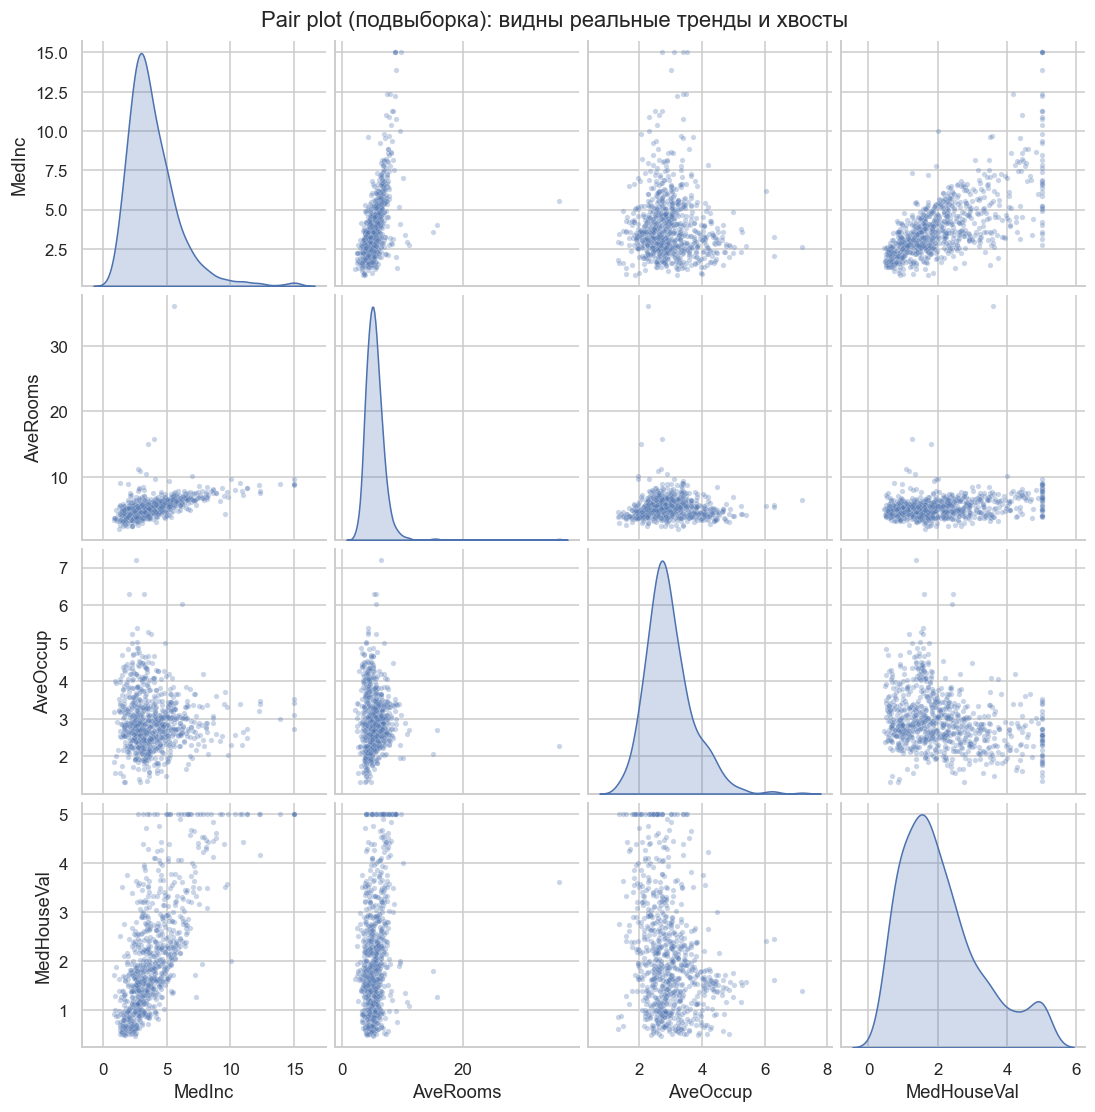

In [14]:
sample = df.sample(800, random_state=42)
g = sns.pairplot(sample[['MedInc','AveRooms','AveOccup','MedHouseVal']],
                 diag_kind='kde', plot_kws=dict(s=12, alpha=0.3))
g.fig.suptitle('Pair plot (подвыборка): видны реальные тренды и хвосты', y=1.01)
plt.show()

In [15]:
def partial_corr(d,x,y,z):
    # частная корреляция x,y при контроле z
    rxy=d[x].corr(d[y]); rxz=d[x].corr(d[z]); ryz=d[y].corr(d[z])
    return (rxy-rxz*ryz)/np.sqrt((1-rxz**2)*(1-ryz**2))

simple = df['AveRooms'].corr(df['MedHouseVal'])
part   = partial_corr(df, 'AveRooms', 'MedHouseVal', 'MedInc')
print(f'AveRooms ~ MedHouseVal  (простая)            : r = {simple:+.3f}')
print(f'AveRooms ~ MedHouseVal  (контроль дохода)    : r = {part:+.3f}')
print(f'AveRooms ~ MedInc                            : r = {df.AveRooms.corr(df.MedInc):+.3f}')
print('\n>>> Связь МЕНЯЕТ ЗНАК с + на -. Дело не в комнатах, а в доходе:')
print('    богатые районы имеют и больше комнат, и более дорогое жильё (доход — конфаундер).')

AveRooms ~ MedHouseVal  (простая)            : r = +0.152
AveRooms ~ MedHouseVal  (контроль дохода)    : r = -0.106
AveRooms ~ MedInc                            : r = +0.327

>>> Связь МЕНЯЕТ ЗНАК с + на -. Дело не в комнатах, а в доходе:
    богатые районы имеют и больше комнат, и более дорогое жильё (доход — конфаундер).


**Вердикт по confounding.** Простая корреляция говорит «больше комнат → дороже» (r=+0.15).
Но при контроле дохода она **переворачивается в −0.11**: при равном доходе район с *большими* домами
(больше комнат на жильё — это пригороды/село) стоит даже *дешевле*. Иллюзию создавал доход —
он одновременно поднимает и число комнат, и цену.

📌 Это и есть «проверка действительности корреляции»: знак связи может развернуться, стоит учесть третий фактор.
Pearson r из раздела 5 — повод копать, а не готовый вывод.

## 7. Сравнение двух групп + t-тест (задание №8): эффект РЕАЛЬНО большой

Делим районы на «богатые» (верхняя треть по доходу) и «бедные» (нижняя треть) и сравниваем цену.
Считаем p-value и Cohen's d.

Бедные районы (n=6880): mean цена = 1.31
Богатые районы (n=6881): mean цена = 2.95
Разница: +1.64 (сотен тыс. $)
t = 100.9,  p-value = 0.00e+00
Cohen's d = 1.72  (>0.8 — БОЛЬШОЙ эффект)


/var/folders/z6/v0mk3q5103g4fgbgkjzr9xsr0000gn/T/ipykernel_56339/2895784720.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=pd.cut(df['MedInc'],[0,lo,hi,df.MedInc.max()],labels=['бедные','средние','богатые']),


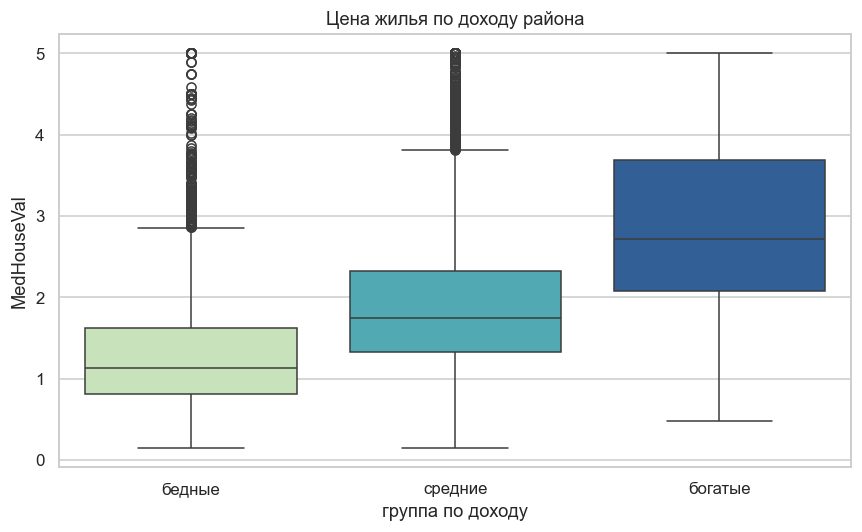

In [16]:
lo = df['MedInc'].quantile(1/3); hi = df['MedInc'].quantile(2/3)
poor = df.loc[df['MedInc']<=lo, 'MedHouseVal']
rich = df.loc[df['MedInc']>=hi, 'MedHouseVal']
t,p = stats.ttest_ind(rich, poor, equal_var=False)
pooled = np.sqrt((rich.std()**2 + poor.std()**2)/2)
d = (rich.mean()-poor.mean())/pooled
print(f'Бедные районы (n={len(poor)}): mean цена = {poor.mean():.2f}')
print(f'Богатые районы (n={len(rich)}): mean цена = {rich.mean():.2f}')
print(f'Разница: {rich.mean()-poor.mean():+.2f} (сотен тыс. $)')
print(f't = {t:.1f},  p-value = {p:.2e}')
print(f"Cohen's d = {d:.2f}  (>0.8 — БОЛЬШОЙ эффект)")
plt.figure(figsize=(8,5))
sns.boxplot(x=pd.cut(df['MedInc'],[0,lo,hi,df.MedInc.max()],labels=['бедные','средние','богатые']),
            y=df['MedHouseVal'], palette='YlGnBu')
plt.xlabel('группа по доходу'); plt.title('Цена жилья по доходу района')
plt.tight_layout(); plt.show()

**Вердикт по t-тесту.** Здесь и p-value ничтожно мал, **и Cohen's d велик** (≫ 0.8) — эффект реальный
и большой. Контраст с синтетикой (там d ≈ 0.04, эффекта не было). Это и есть честный «значимый» результат:
малый p подкреплён большим размером эффекта.

## 8. 🎭 Статистика, которая врёт — на реальных данных

В синтетике мы добывали ложную связь из шума (p-hacking). На реальных данных ложь приходит иначе —
через **дефекты данных**. Два честных примера и одна проверка устойчивости.

In [17]:
# ЛОЖЬ №1 — ЦЕНЗУРА занижает среднюю цену
cap = df['MedHouseVal'].max(); capped = df['MedHouseVal']>=cap-1e-6
print('Записанное среднее цены        :', round(df['MedHouseVal'].mean(),3))
print(f'Из них {capped.sum()} домов обрезаны на потолке {cap:.2f} — их РЕАЛЬНАЯ цена выше.')
print('=> Истинное среднее БОЛЬШЕ записанного. Статистика занижена самой обрезкой данных.')

Записанное среднее цены        : 2.069
Из них 965 домов обрезаны на потолке 5.00 — их РЕАЛЬНАЯ цена выше.
=> Истинное среднее БОЛЬШЕ записанного. Статистика занижена самой обрезкой данных.


In [18]:
# ЛОЖЬ №2 — ВЫБРОС раздувает среднюю заселённость
ao = df['AveOccup']
print(f'AveOccup: записанное среднее = {ao.mean():.2f}, медиана = {ao.median():.2f}')
print(f'Уберём {int((ao>=ao.quantile(0.999)).sum())} район(ов) с явными ошибками (топ 0.1%):',
      f'среднее -> {ao[ao<ao.quantile(0.999)].mean():.2f}')
print('=> Несколько ошибочных точек двигают «среднюю заселённость города». Медиана им не поддалась.')

AveOccup: записанное среднее = 3.07, медиана = 2.82
Уберём 21 район(ов) с явными ошибками (топ 0.1%): среднее -> 2.93
=> Несколько ошибочных точек двигают «среднюю заселённость города». Медиана им не поддалась.


In [19]:
# ПРОВЕРКА устойчивости: настоящая связь доход~цена выживает на 50 случайных подвыборках
rs = []
for i in range(50):
    sub = df.sample(500, random_state=i)
    rs.append(stats.pearsonr(sub['MedInc'], sub['MedHouseVal'])[0])
rs = np.array(rs)
print(f'r(доход, цена) на 50 подвыборках по 500: среднее = {rs.mean():.3f}, '
      f'разброс [{rs.min():.3f}; {rs.max():.3f}]')
print('=> Связь стабильна везде. В отличие от синтетического «призрака», она не исчезает при перепроверке.')

r(доход, цена) на 50 подвыборках по 500: среднее = 0.691, разброс [0.617; 0.746]
=> Связь стабильна везде. В отличие от синтетического «призрака», она не исчезает при перепроверке.


**Вердикт.** На реальных данных статистика врёт не от пустоты, а от **скрытых дефектов**:
цензура занижает среднюю цену, единичные выбросы раздувают среднюю заселённость. Но настоящая связь
(доход → цена) **устойчива** к перепроверке — это и отличает сигнал от призрака из первого ноутбука.

## 9. Проверка руками (привычка №3)

In [20]:
head10 = df['MedInc'].head(10).tolist()
manual = sum(head10)/len(head10); pandas_mean = df['MedInc'].head(10).mean()
print('Первые 10 значений MedInc:', [round(v,3) for v in head10])
print(f'Руками: {manual:.6f} | pandas: {pandas_mean:.6f} | совпадает: {np.isclose(manual,pandas_mean)}')

Первые 10 значений MedInc: [8.325, 8.301, 7.257, 5.643, 3.846, 4.037, 3.659, 3.12, 2.08, 3.691]
Руками: 4.996080 | pandas: 4.996080 | совпадает: True


## 10. Мини-расследование + сравнение двух датасетов

| # | Вопрос | Число | Проверка | Вердикт |
|---|--------|-------|----------|---------|
| 1 | Данные чистые? | 0 пропусков, но 4.8% цены обрезаны | потолок $500k, выбросы AveRooms/AveOccup | Чисто от NaN, но есть **цензура и выбросы** |
| 2 | Среднее цены врёт? | mean 2.07 > median 1.80, skew +0.98 | сравнение mean/median | **Скос вправо** — среднее завышает «типичный» район |
| 3 | Распределения нормальные? | Shapiro p<0.05 | Q-Q (скос вверх) + пик цензуры | НЕТ — **скошены**, не равномерны |
| 4 | Есть ли связь? | r(доход, цена) ≈ 0.69 | корреляция + 50 подвыборок | **Настоящая и устойчивая** связь |
| 5 | Связь комнат и цены реальна? | r: +0.15 → −0.11 | частная корреляция (контроль дохода) | **Confounding**: знак переворачивается |

### ⚔️ Синтетика vs Реальность

| Свойство | Smart Traffic (синтетика) | California Housing (реал) |
|----------|---------------------------|---------------------------|
| Пропуски/дубли | 0 (подозрительно идеально) | 0, но есть цензура и выбросы |
| Форма | равномерная (плоская) | скошенная вправо |
| mean vs median | совпадают | расходятся (скос) |
| Выбросы | нет | реальные, длинные хвосты |
| Корреляции | ≈ 0 (шум) | сильные (доход→цена 0.69) |
| Confounding | нечего проверять | связь меняет знак |
| t-тест (Cohen's d) | ≈ 0.04 (нет эффекта) | ≫ 0.8 (большой эффект) |
| Как врёт статистика | p-hacking из шума | цензура + выбросы данных |

### 🎯 Открытие за 30 секунд
> «Реальные данные о жилье врут не как синтетика. Здесь среднее цены завышено скосом и одновременно
> занижено цензурой ($500k-потолок), один район с 1243 жильцами раздувает среднюю заселённость,
> а "больше комнат → дороже" переворачивается в минус, стоит учесть доход. Но настоящая связь
> доход→цена (r=0.69) выдержала 50 перепроверок — это сигнал, а не призрак.»

---
*Формулы посчитала машина. Скепсис остался за мной.* 🕵️

# 🔬 11. Review всех связей: что меняется при контроле остальных признаков

В разделе 6 мы разобрали одну пару (комнаты ~ цена). Теперь проверим **все** признаки разом:
сравним простую корреляцию с ценой и коэффициент регрессии, где *одновременно* учтены все остальные
признаки (это многомерный аналог частной корреляции). Где знак меняется — там пряталось искажение.

In [21]:
import statsmodels.api as sm
feats  = ['MedInc','HouseAge','AveRooms','AveBedrms','Population','AveOccup','Latitude','Longitude']
target = 'MedHouseVal'
# стандартизуем, чтобы коэффициенты были сопоставимы (как корреляции)
Z = (df[feats+[target]] - df[feats+[target]].mean()) / df[feats+[target]].std()
ols = sm.OLS(Z[target], sm.add_constant(Z[feats])).fit()

review = pd.DataFrame({
    'simple_r'              : [df[f].corr(df[target]) for f in feats],
    'beta (контроль всех)'  : [ols.params[f] for f in feats],
}, index=feats)
review['знак сменился?'] = np.where(
    np.sign(review['simple_r']) != np.sign(review['beta (контроль всех)']), 'ДА', '')
print('R^2 полной модели:', round(ols.rsquared, 3))
review.round(3)

R^2 полной модели: 0.606


,simple_r,beta (контроль всех),знак сменился?
MedInc,0.688,0.719,
HouseAge,0.106,0.103,
AveRooms,0.152,-0.230,ДА
AveBedrms,-0.047,0.265,ДА
Population,-0.025,-0.004,
AveOccup,-0.024,-0.034,
Latitude,-0.144,-0.780,
Longitude,-0.046,-0.754,


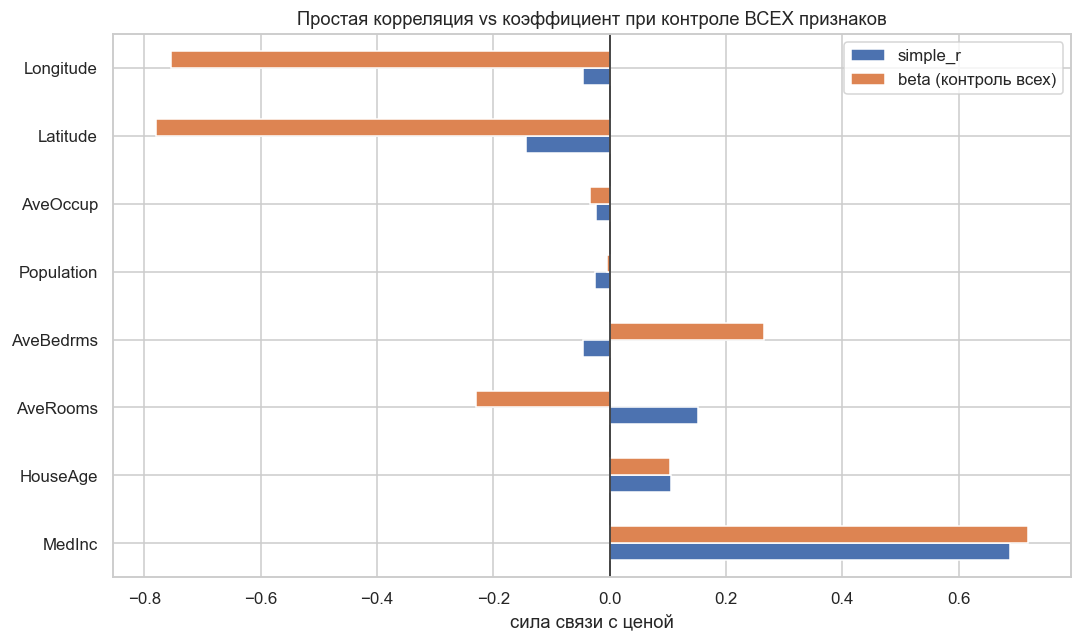

In [22]:
ax = review[['simple_r','beta (контроль всех)']].plot.barh(figsize=(10,6))
ax.axvline(0, color='k', lw=1)
ax.set_title('Простая корреляция vs коэффициент при контроле ВСЕХ признаков')
ax.set_xlabel('сила связи с ценой')
plt.tight_layout(); plt.show()

**Вердикт по связям.** Картина «больше комнат → дороже» была не единственной иллюзией:

- **`AveRooms`**: simple +0.15 → beta **−0.23** (знак сменился). Конфаундер — доход.
- **`AveBedrms`**: simple −0.05 → beta **+0.27** (знак сменился). При равных комнатах больше спален = чуть дороже,
  но в одиночку признак выглядел нейтральным — его маскировала корреляция с `AveRooms`.
- **`Latitude`/`Longitude`**: маленькая простая связь (−0.14 / −0.05), но огромные beta (−0.78 / −0.75).
  Это **подавление (suppression)**: по отдельности гео-координата почти ни о чём, но вместе они кодируют
  «насколько южнее и западнее = ближе к побережью = дороже». География — мощнейший фактор после дохода.
- **`MedInc`** — единственный, кто и в простой, и в полной модели сильнейший (+0.69 / +0.72). Настоящий драйвер.

📌 Простая корреляция — это первый взгляд. Истину показывает только модель, где факторы конкурируют за объяснение.

# 🧪 12. Что будет, если убрать колонку (ablation + omitted variable bias)

Два эксперимента: (1) убираем по одному признаку из модели и смотрим, насколько просядет R²
(кто реально несёт сигнал); (2) убираем **конфаундер** и наблюдаем, как оживает ложная связь.

In [23]:
full_r2 = ols.rsquared
drops = []
for f in feats:
    sub = [c for c in feats if c != f]
    r2 = sm.OLS(Z[target], sm.add_constant(Z[sub])).fit().rsquared
    drops.append({'убрали колонку': f, 'R2 без неё': round(r2,3), 'падение R2': round(full_r2-r2,4)})
drops = pd.DataFrame(drops).sort_values('падение R2', ascending=False).reset_index(drop=True)
print('R2 полной модели:', round(full_r2,3))
drops

R2 полной модели: 0.606


,убрали колонку,R2 без неё,падение R2
0,MedInc,0.400,0.2066
1,Latitude,0.541,0.0654
2,Longitude,0.543,0.0635
3,AveBedrms,0.596,0.0100
4,HouseAge,0.598,0.0085
5,AveRooms,0.600,0.0063
6,AveOccup,0.605,0.0012
7,Population,0.606,0.0000


/var/folders/z6/v0mk3q5103g4fgbgkjzr9xsr0000gn/T/ipykernel_56339/4263850251.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=drops, y='убрали колонку', x='падение R2', palette='Reds_r')


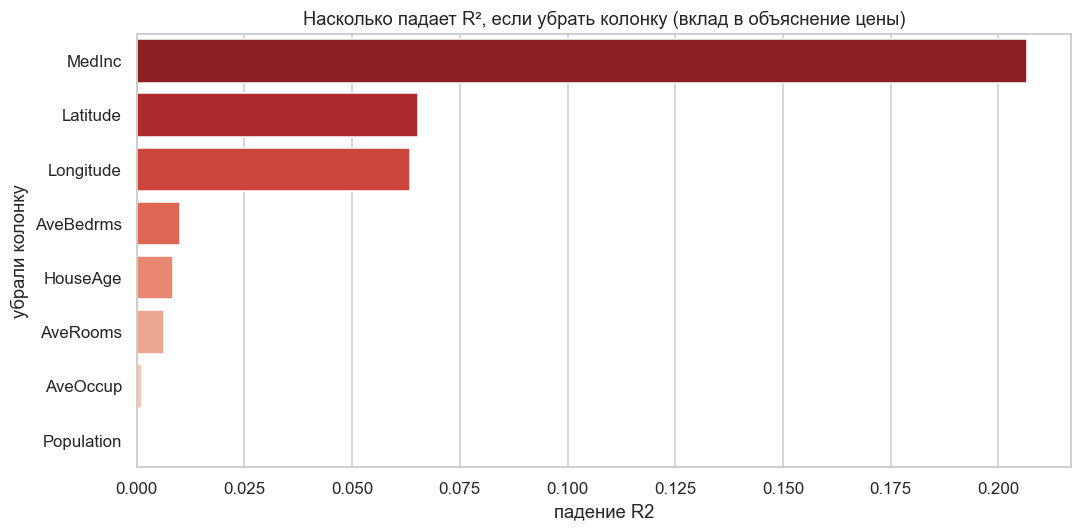

In [24]:
plt.figure(figsize=(10,5))
sns.barplot(data=drops, y='убрали колонку', x='падение R2', palette='Reds_r')
plt.title('Насколько падает R², если убрать колонку (вклад в объяснение цены)')
plt.tight_layout(); plt.show()

In [25]:
# OMITTED VARIABLE BIAS: коэффициент AveRooms с доходом и без
b_alone = sm.OLS(Z[target], sm.add_constant(Z[['AveRooms']])).fit().params['AveRooms']
b_ctrl  = sm.OLS(Z[target], sm.add_constant(Z[['AveRooms','MedInc']])).fit().params['AveRooms']
print(f'AveRooms БЕЗ дохода в модели : beta = {b_alone:+.3f}  -> «больше комнат = дороже»')
print(f'AveRooms С доходом в модели  : beta = {b_ctrl:+.3f}  -> правда: при равном доходе ДЕШЕВЛЕ')
print('\n>>> Стоит выкинуть конфаундер (доход) — и ложная положительная связь возвращается как «реальная».')
print('>>> Это omitted variable bias: пропущенная переменная переписывает выводы.')

AveRooms БЕЗ дохода в модели : beta = +0.152  -> «больше комнат = дороже»
AveRooms С доходом в модели  : beta = -0.082  -> правда: при равном доходе ДЕШЕВЛЕ

>>> Стоит выкинуть конфаундер (доход) — и ложная положительная связь возвращается как «реальная».
>>> Это omitted variable bias: пропущенная переменная переписывает выводы.


**Вердикт по ablation.**
- **Сигнал держится на немногих колонках.** Убрать `MedInc` → R² рушится 0.61 → 0.40. Убрать `Latitude`/`Longitude` →
  −0.06 каждая. А `Population`, `AveOccup`, `AveRooms`, `AveBedrms`, `HouseAge` можно выкинуть почти без потерь
  (−0.01 и меньше) — по отдельности они мало что добавляют поверх дохода и географии.
- **Omitted variable bias — главная ловушка.** Уберёшь доход из модели — и `AveRooms` снова «доказывает»,
  что комнаты повышают цену (+0.15). Это ровно тот механизм, которым отчёты обманывают: показать связь,
  *умолчав* о третьей переменной, которая всё объясняет.

# ✂️ 13. Что будет, если обрезать колонку (выбросы и цензура)

Обрезка — не косметика. Покажем три случая, где удаление «кривых» значений **меняет вывод**.

In [26]:
rows = []
cap = df[target].max()
# 1) убрать цензурированные дома (цена упёрта в потолок)
nocap = df[df[target] < cap - 1e-6]
rows.append({'операция':'убрать цензуру (цена = потолок $500k)','связь':'corr(MedInc, price)',
             'было':round(df['MedInc'].corr(df[target]),3),
             'стало':round(nocap['MedInc'].corr(nocap[target]),3)})
# 2) обрезать топ-1% выбросов AveOccup
q=df['AveOccup'].quantile(0.99); t=df[df['AveOccup']<q]
rows.append({'операция':'убрать топ-1% AveOccup (выбросы)','связь':'corr(AveOccup, price)',
             'было':round(df['AveOccup'].corr(df[target]),3),
             'стало':round(t['AveOccup'].corr(t[target]),3)})
# 3) обрезать топ-1% выбросов AveRooms
q=df['AveRooms'].quantile(0.99); t=df[df['AveRooms']<q]
rows.append({'операция':'убрать топ-1% AveRooms (выбросы)','связь':'corr(AveRooms, price)',
             'было':round(df['AveRooms'].corr(df[target]),3),
             'стало':round(t['AveRooms'].corr(t[target]),3)})
trunc = pd.DataFrame(rows)
trunc['изменение'] = (trunc['стало']-trunc['было']).round(3)
trunc

,операция,связь,было,стало,изменение
0,убрать цензуру (цена = потолок $500k),"corr(MedInc, price)",0.688,0.643,-0.045
1,убрать топ-1% AveOccup (выбросы),"corr(AveOccup, price)",-0.024,-0.280,-0.256
2,убрать топ-1% AveRooms (выбросы),"corr(AveRooms, price)",0.152,0.329,0.177


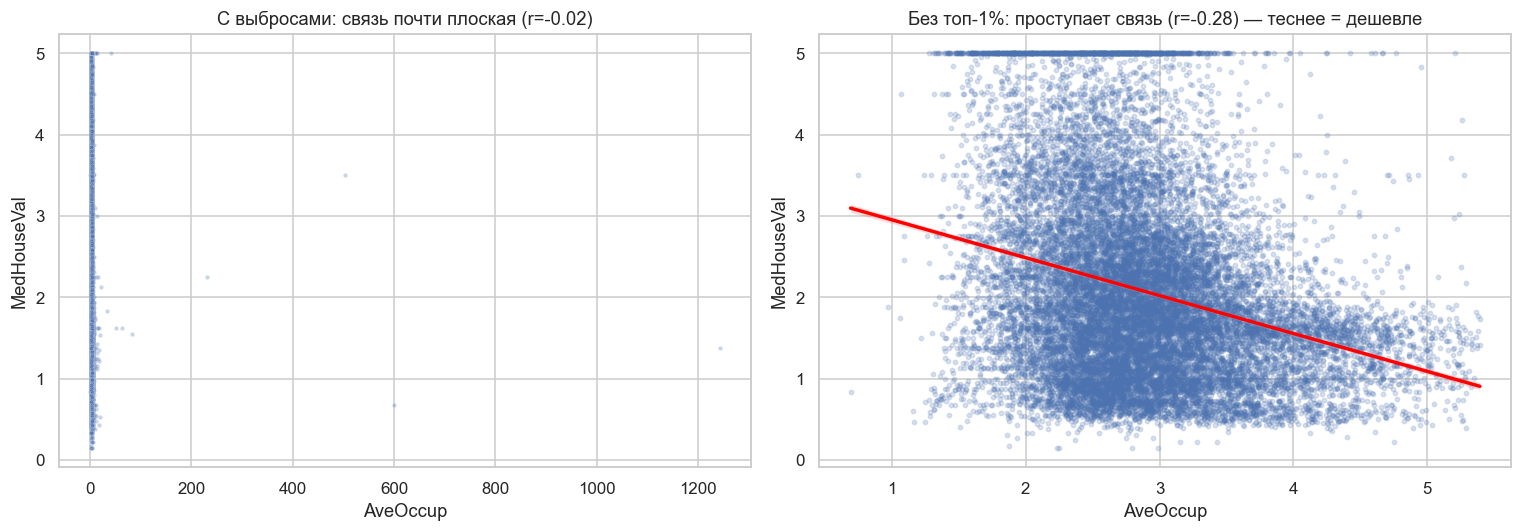

In [27]:
# Наглядно: выбросы AveOccup ПРЯТАЛИ реальную отрицательную связь с ценой
q = df['AveOccup'].quantile(0.99); clean = df[df['AveOccup'] < q]
fig, ax = plt.subplots(1, 2, figsize=(14,5))
sns.scatterplot(x='AveOccup', y=target, data=df, s=8, alpha=.3, ax=ax[0])
ax[0].set_title(f'С выбросами: связь почти плоская (r={df.AveOccup.corr(df[target]):.2f})')
sns.regplot(x='AveOccup', y=target, data=clean, scatter_kws=dict(s=8,alpha=.2),
            line_kws=dict(color='red'), ax=ax[1])
ax[1].set_title(f'Без топ-1%: проступает связь (r={clean.AveOccup.corr(clean[target]):.2f}) — теснее = дешевле')
plt.tight_layout(); plt.show()

**Вердикт по обрезке.** Удаление значений меняет не цифру после запятой, а сам вывод:

- **Выбросы могут ПРЯТАТЬ связь.** `corr(AveOccup, price)` был ≈ **−0.02** («связи нет») — но это эффект
  нескольких районов с заселённостью в сотни человек. Уберём топ-1% → corr становится **−0.28**:
  чем теснее живут, тем жильё дешевле. Реальная связь была погребена под выбросами.
- **Выбросы могут РАЗМЫВАТЬ связь.** `corr(AveRooms, price)` 0.15 → **0.33** после обрезки — выбросы её ослабляли.
- **Цензура завышает связь.** `corr(MedInc, price)` 0.69 → **0.64** без обрезанных домов: потолок $500k
  искусственно «выпрямляет» верх облака и раздувает корреляцию.

📌 Поэтому к любому числу — вопрос: *на каких строках оно посчитано и что выкинули перед подсчётом?*
Обрезка выбросов и цензура способны и создать связь, и убить её.

# 🧾 14. Итог review

| Что проверяли | Находка | Чему учит |
|---------------|---------|-----------|
| Все связи при контроле остальных | `AveRooms` +→−, `AveBedrms` −→+, гео даёт suppression | Простая корреляция врёт; нужна модель |
| Drop-one (важность колонок) | Сигнал на `MedInc` (−0.21 R²) и гео; остальное лишнее | Объяснение держится на 2–3 признаках |
| Убрать конфаундер (доход) | `AveRooms` beta +0.15 → −0.08 | **Omitted variable bias** — ложная связь оживает |
| Обрезать выбросы `AveOccup` | corr −0.02 → −0.28 | Выбросы **прячут** реальную связь |
| Обрезать выбросы `AveRooms` | corr 0.15 → 0.33 | Выбросы **размывают** связь |
| Убрать цензуру цены | corr 0.69 → 0.64 | Цензура **завышает** корреляцию |

> **Главный вывод review:** ни одну связь в реальных данных нельзя брать по простой корреляции.
> Знак переворачивается при контроле конфаундера, важность колонки видна только в ablation,
> а обрезка выбросов/цензуры способна и создать связь, и стереть её. Скепсис — не к данным, а к каждому числу.

In [1]:
# Conclusion with price
цена [4.0–4.2): 226 районов
цена [4.2–4.4): 182
цена [4.4–4.6): 178
цена [4.6–4.8): 106
цена [4.8–4.999):  87   ← плавно убывает
цена  ровно 5.0:  965   ← резкий ВСПЛЕСК в 11 раз

SyntaxError: invalid character '–' (U+2013) (4017509415.py, line 2)